In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/crime_cleaned.csv", encoding="latin1")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313637 entries, 0 to 313636
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   INCIDENT_NUMBER     313637 non-null  object 
 1   OFFENSE_CODE        313637 non-null  int64  
 2   OFFENSE_CODE_GROUP  313637 non-null  object 
 3   DISTRICT            313637 non-null  object 
 4   REPORTING_AREA      313637 non-null  object 
 5   OCCURRED_ON_DATE    313637 non-null  object 
 6   STREET              313637 non-null  object 
 7   Lat                 294277 non-null  float64
 8   Long                294277 non-null  float64
 9   NAME                313637 non-null  object 
 10  HAS_LOCATION        313637 non-null  int64  
 11  hour                313637 non-null  int64  
 12  day_name            313637 non-null  object 
 13  day                 313637 non-null  int64  
 14  month_name          313637 non-null  object 
 15  month               313637 non-nul

In [4]:
df.isna().sum()

INCIDENT_NUMBER           0
OFFENSE_CODE              0
OFFENSE_CODE_GROUP        0
DISTRICT                  0
REPORTING_AREA            0
OCCURRED_ON_DATE          0
STREET                    0
Lat                   19360
Long                  19360
NAME                      0
HAS_LOCATION              0
hour                      0
day_name                  0
day                       0
month_name                0
month                     0
year                      0
time_of_day               0
dtype: int64

In [5]:
df.head(5)

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,DISTRICT,REPORTING_AREA,OCCURRED_ON_DATE,STREET,Lat,Long,NAME,HAS_LOCATION,hour,day_name,day,month_name,month,year,time_of_day
0,I182070945,619,Larceny,D14,808,2018-09-02 13:00:00,LINCOLN ST,42.357791,-71.139371,LARCENY OTHER $200 & OVER,1,13,Sunday,2,September,9,2018,Afternoon
1,I182070885,619,Larceny,B3,456,2018-09-03 17:17:00,ELLINGTON ST,42.301546,-71.081182,LARCENY OTHER $200 & OVER,1,17,Monday,3,September,9,2018,Afternoon
2,I182070816,619,Larceny,C6,185,2018-09-03 12:45:00,MASSACHUSETTS AVE,42.321987,-71.062807,LARCENY OTHER $200 & OVER,1,12,Monday,3,September,9,2018,Morning
3,I182070777,619,Larceny,C11,388,2018-08-23 13:34:00,ADAMS ST,42.272306,-71.067214,LARCENY OTHER $200 & OVER,1,13,Thursday,23,August,8,2018,Afternoon
4,I182070707,619,Larceny,D14,782,2018-09-02 23:12:00,GORDON ST,42.352935,-71.140501,LARCENY OTHER $200 & OVER,1,23,Sunday,2,September,9,2018,Night


In [6]:
df.describe()

,OFFENSE_CODE,Lat,Long,HAS_LOCATION,hour,day,month,year
count,313637.000000,294277.000000,294277.000000,313637.000000,313637.000000,313637.000000,313637.000000,313637.000000
mean,2311.675711,42.215471,-70.909961,0.938273,13.125591,15.746270,6.611449,2016.561244
std,1192.924585,2.149385,3.476820,0.240660,6.292626,8.834334,3.273866,0.995966
min,111.000000,-1.000000,-71.178674,0.000000,0.000000,1.000000,1.000000,2015.000000
25%,802.000000,42.297466,-71.097158,1.000000,9.000000,8.000000,4.000000,2016.000000
50%,3002.000000,42.325600,-71.077526,1.000000,14.000000,16.000000,7.000000,2017.000000
75%,3201.000000,42.348624,-71.062467,1.000000,18.000000,23.000000,9.000000,2017.000000
max,3831.000000,42.395042,-1.000000,1.000000,23.000000,31.000000,12.000000,2018.000000


In [7]:
#filling missing values in the categorical data
df["DISTRICT"]=df["DISTRICT"].fillna("UNKNOWN")
df["STREET"]=df["STREET"].fillna("UNKNOWN")


In [8]:
#making a new column of lat long for project
df["HAS_LOCATION"]=(df["Lat"].notna() & df["Long"].notna()).astype(int)

In [9]:
df["OCCURRED_ON_DATE"] = pd.to_datetime(df["OCCURRED_ON_DATE"], dayfirst=True, errors="coerce")

In [10]:
#extracting core time features for prject use
df["hour"]=df["OCCURRED_ON_DATE"].dt.hour
df["day_name"]=df["OCCURRED_ON_DATE"].dt.day_name()
df["day"]=df["OCCURRED_ON_DATE"].dt.day
df["month_name"]=df["OCCURRED_ON_DATE"].dt.month_name()
df["month"]=df["OCCURRED_ON_DATE"].dt.month
df["year"]=df["OCCURRED_ON_DATE"].dt.year


In [11]:
#making time of day function + feature
def time_of_day(hour):
    if  5<=hour<=12:
        return "Morning"
    elif 12<=hour<=17:
        return "Afternoon"
    elif  17<=hour<=21:
        return "Evening"
    else:
        return "Night"
df["time_of_day"]=df["hour"].apply(time_of_day)

In [12]:
df["hour"]=df["hour"].astype("Int64")
df["day"]=df["day"].astype("Int64")
df["month"]=df["month"].astype("Int64")
df["year"]=df["year"].astype("Int64")

In [13]:
df["DISTRICT"].describe()

count     313637
unique        13
top           B2
freq       48853
Name: DISTRICT, dtype: object

In [14]:
#district with highest crime rate
df.groupby("DISTRICT").size().sort_values(ascending=False).idxmax()

'B2'

In [15]:
#area with highest crime count
df.groupby("REPORTING_AREA").size().sort_values(ascending=False).head(1)

REPORTING_AREA
    19603
dtype: int64

In [16]:
#crime count for each reporting area in each district
df.groupby(["DISTRICT","REPORTING_AREA"]).size().reset_index(name="crime_count")

,DISTRICT,REPORTING_AREA,crime_count
0,A1,,3379
1,A1,0,1
2,A1,100,350
3,A1,101,503
4,A1,102,1151
...,...,...,...
1240,UNKNOWN,511,1
1241,UNKNOWN,611,2
1242,UNKNOWN,714,1
1243,UNKNOWN,914,1


In [17]:
#crime count for each street in each reporting area of each district
df.groupby(["DISTRICT","REPORTING_AREA","STREET"]).size().reset_index(name="crime_count")

,DISTRICT,REPORTING_AREA,STREET,crime_count
0,A1,,4 NORTH SQ,1
1,A1,,5 REVERE ST,2
2,A1,,93 S,1
3,A1,,ACCOLON WAY,1
4,A1,,ANDERSON ST,2
...,...,...,...,...
10877,UNKNOWN,611,HUNTINGTON AVE,1
10878,UNKNOWN,611,JAMAICAWAY,1
10879,UNKNOWN,714,WASHINGTON ST,1
10880,UNKNOWN,914,MONSIGNOR DENNIS F O'CALL,1


In [18]:
#crime count by area
df.groupby("REPORTING_AREA").size().reset_index(name="crime_count")

,REPORTING_AREA,crime_count
0,,19603
1,0,11
2,1,35
3,10,184
4,100,350
...,...,...
874,961,32
875,962,58
876,97,347
877,98,353


In [19]:
#crime count by group
df.groupby("OFFENSE_CODE_GROUP").size().reset_index(name="crime_count")

,OFFENSE_CODE_GROUP,crime_count
0,Aggravated Assault,7807
1,Aircraft,36
2,Arson,94
3,Assembly or Gathering Violations,955
4,Auto Theft,4851
...,...,...
62,Towed,11287
63,Vandalism,15415
64,Verbal Disputes,13099
65,Violations,3479


In [20]:
#top 20 districts with highest number of crimes
df.groupby("DISTRICT").size().sort_values(ascending=False).head(20)
#note - there are only 13 districts in the dataset

DISTRICT
B2         48853
C11        41664
D4         41356
A1         35351
B3         34878
C6         23044
D14        19888
E13        17175
E18        17119
A7         13275
E5         12932
A15         6394
UNKNOWN     1708
dtype: int64

In [21]:
#reporting area with highest crime count
df.groupby("REPORTING_AREA").size().sort_values(ascending=False).head(1)


REPORTING_AREA
    19603
dtype: int64

In [22]:
#top 20 streets with highest number of crimes
top_street=df.groupby("STREET").size().sort_values(ascending=False).reset_index(name="crime count")
top_street.head(20)

,STREET,crime count
0,WASHINGTON ST,14000
1,UNKNOWN,10507
2,BLUE HILL AVE,7618
3,BOYLSTON ST,7160
4,DORCHESTER AVE,5036
5,TREMONT ST,4720
6,MASSACHUSETTS AVE,4606
7,HARRISON AVE,4537
8,CENTRE ST,4289
9,COMMONWEALTH AVE,4087


In [23]:
#top 20 streets with highest crime rate
#crime rate = street crime count/total crime commited in that district
#frist calculate the street crime count
street_counts= df.groupby(["DISTRICT","REPORTING_AREA","STREET"]).size().reset_index(name="street_counts")
street_counts

,DISTRICT,REPORTING_AREA,STREET,street_counts
0,A1,,4 NORTH SQ,1
1,A1,,5 REVERE ST,2
2,A1,,93 S,1
3,A1,,ACCOLON WAY,1
4,A1,,ANDERSON ST,2
...,...,...,...,...
10877,UNKNOWN,611,HUNTINGTON AVE,1
10878,UNKNOWN,611,JAMAICAWAY,1
10879,UNKNOWN,714,WASHINGTON ST,1
10880,UNKNOWN,914,MONSIGNOR DENNIS F O'CALL,1


In [24]:
#then calculate total crime per reporting area in that district/area
area_count=df.groupby(["DISTRICT","REPORTING_AREA"]).size().reset_index(name="area_count")
area_count


,DISTRICT,REPORTING_AREA,area_count
0,A1,,3379
1,A1,0,1
2,A1,100,350
3,A1,101,503
4,A1,102,1151
...,...,...,...
1240,UNKNOWN,511,1
1241,UNKNOWN,611,2
1242,UNKNOWN,714,1
1243,UNKNOWN,914,1


In [25]:
#merge
street_rates= street_counts.merge(area_count,on=["DISTRICT","REPORTING_AREA"],how="left")

In [26]:
#calculate crime rate
street_rates["street_rates"]=(street_rates["street_counts"]/street_rates["area_count"])

In [27]:
#now the answer with top 20 street with highest crime rate
top_crime_streets= street_rates.sort_values(by="street_rates",ascending=False)
top_crime_streets.head(20)

,DISTRICT,REPORTING_AREA,STREET,street_counts,area_count,street_rates
10445,E5,932,WASHINGTON ST,80,80,1.0
10867,UNKNOWN,184,UNKNOWN,2,2,1.0
10881,UNKNOWN,959,DORCHESTER AVE,6,6,1.0
10444,E5,914,DR. MICHAEL GAVIN WAY,6,6,1.0
10880,UNKNOWN,914,MONSIGNOR DENNIS F O'CALL,1,1,1.0
8691,E18,469,UNKNOWN,1,1,1.0
8690,E18,403,UNKNOWN,1,1,1.0
8689,E18,184,UNKNOWN,2,2,1.0
8620,E13,949,UNKNOWN,1,1,1.0
1665,A7,629,MONMOUTH ST,1,1,1.0


In [28]:
#crime type that occured most frequently by time of day
c_t=df.groupby(["time_of_day","OFFENSE_CODE_GROUP"]).size().reset_index(name="crime_count")
result= c_t.loc[(c_t.groupby("time_of_day")["crime_count"]).idxmax()]
result

,time_of_day,OFFENSE_CODE_GROUP,crime_count
40,Afternoon,Motor Vehicle Accident Response,4287
103,Evening,Motor Vehicle Accident Response,2901
164,Morning,Motor Vehicle Accident Response,4604
230,Night,Motor Vehicle Accident Response,25340


In [29]:
#crime count by time of day for each crime type
d_t=df.groupby(["time_of_day","OFFENSE_CODE_GROUP"]).size().reset_index(name="crime_count")
d_t

,time_of_day,OFFENSE_CODE_GROUP,crime_count
0,Afternoon,Aggravated Assault,762
1,Afternoon,Aircraft,6
2,Afternoon,Arson,10
3,Afternoon,Assembly or Gathering Violations,45
4,Afternoon,Auto Theft,475
...,...,...,...
249,Night,Towed,7506
250,Night,Vandalism,11009
251,Night,Verbal Disputes,9067
252,Night,Violations,2398


In [30]:
#crime count for time of day for each day of week
weeked = df.groupby(["time_of_day","day_name","OFFENSE_CODE_GROUP"]).size().reset_index(name="crime_count")
weeked.sort_values(by="time_of_day",)

,time_of_day,day_name,OFFENSE_CODE_GROUP,crime_count
0,Afternoon,Friday,Aggravated Assault,112
275,Afternoon,Thursday,Phone Call Complaints,1
274,Afternoon,Thursday,Other Burglary,7
273,Afternoon,Thursday,Other,325
272,Afternoon,Thursday,Operating Under the Influence,2
...,...,...,...,...
1318,Night,Saturday,Evading Fare,3
1317,Night,Saturday,Embezzlement,1
1316,Night,Saturday,Drug Violation,84
1314,Night,Saturday,Criminal Harassment,3


<Axes: xlabel='Long', ylabel='Lat'>

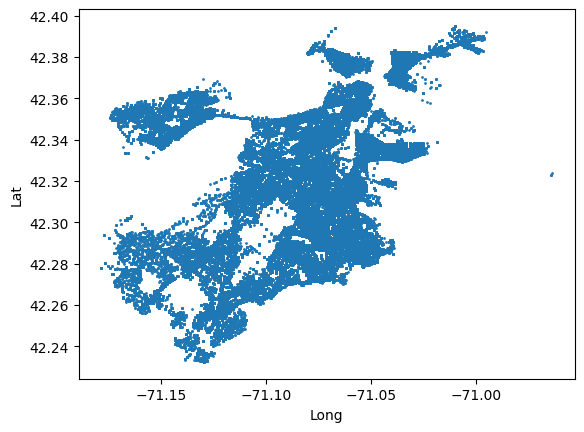

In [31]:
#scatter plot of crime based on lat and lon
#we gotta clean missing values
geo_clean=df[(df["Lat"]>40)&(df["Lat"]<43) &(df["Long"]<-70) &(df["Long"]>-72)]
geo_clean.plot(kind="scatter",x="Long",y="Lat",s=1)

In [32]:
#top 5 crime types committed in top 5 street
top_streets= (df[df["STREET"]!="UNKNOWN"].groupby("STREET").size().reset_index(name="total_crimes").sort_values(by="total_crimes",ascending=False).head(5))


In [33]:
tops = top_streets["STREET"]
res= df[df["STREET"].isin(tops)].groupby(["STREET","OFFENSE_CODE_GROUP"]).size().reset_index(name="crime_count").sort_values(by="crime_count",ascending=False)
res.sort_values(by="crime_count",ascending=False).head(5)

,STREET,OFFENSE_CODE_GROUP,crime_count
79,BOYLSTON ST,Larceny,2163
249,WASHINGTON ST,Larceny,1933
32,BLUE HILL AVE,Motor Vehicle Accident Response,1246
234,WASHINGTON ST,Drug Violation,1160
258,WASHINGTON ST,Motor Vehicle Accident Response,1130


In [34]:
#top 5 crimes in top 5 districts
top_dis=df.groupby(["DISTRICT","OFFENSE_CODE_GROUP"]).size().reset_index(name="total_crimes").sort_values(by="total_crimes",ascending=False).head(5)

In [35]:
top=top_dis["DISTRICT"]
res= df[df["DISTRICT"].isin(top)].groupby(["DISTRICT","OFFENSE_CODE_GROUP"]).size().reset_index(name="crime_count").sort_values(by="crime_count",ascending=False).head(5)
res

,DISTRICT,OFFENSE_CODE_GROUP,crime_count
211,D4,Larceny,7313
97,B2,Motor Vehicle Accident Response,6407
159,C11,Motor Vehicle Accident Response,5305
28,A1,Larceny,4704
219,D4,Motor Vehicle Accident Response,3882


In [36]:
#top 5 crimes in top 5 reporting areas
top_rep = df.groupby("REPORTING_AREA").size().reset_index(name="total_report").sort_values(by="total_report",ascending=False).head(5)


In [37]:
res= df[df["REPORTING_AREA"].isin(top_rep["REPORTING_AREA"])].groupby(["REPORTING_AREA","OFFENSE_CODE_GROUP"]).size().reset_index(name="crime_count").sort_values(by="crime_count",ascending=False).head(5)
res

,REPORTING_AREA,OFFENSE_CODE_GROUP,crime_count
35,,Motor Vehicle Accident Response,6574
12,,Drug Violation,1765
32,,Medical Assistance,1012
38,,Other,907
52,,Simple Assault,824


In [38]:
#number of crimes commited on each day of every month
day_months=df.groupby(["month","day"]).size().reset_index(name="crime_count").sort_values(["month","day"])
day_months

,month,day,crime_count
0,1,1,879
1,1,2,864
2,1,3,834
3,1,4,877
4,1,5,896
...,...,...,...
139,12,8,1063
140,12,9,865
141,12,10,791
142,12,11,754


In [39]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

df["day_name"] = pd.Categorical(
    df["day_name"],
    categories=day_order,
    ordered=True
)
time_order= ["Morning","Afternoon","Evening","Night"]
df["time_of_day"]=pd.Categorical(df["time_of_day"],categories=time_order,ordered=True)

In [40]:
#number of crime committed in each district by time of day and day of week
dis_time_week= df[df["DISTRICT"]!="UNKNOWN"].groupby(["DISTRICT","day_name","time_of_day"],observed=True).size().reset_index(name="crime_count").sort_values(["DISTRICT","day_name","time_of_day"])
dis_time_week



,DISTRICT,day_name,time_of_day,crime_count
0,A1,Monday,Morning,574
1,A1,Monday,Afternoon,533
2,A1,Monday,Evening,364
3,A1,Monday,Night,494
4,A1,Tuesday,Morning,542
...,...,...,...,...
331,E5,Saturday,Night,124
332,E5,Sunday,Morning,270
333,E5,Sunday,Afternoon,240
334,E5,Sunday,Evening,136


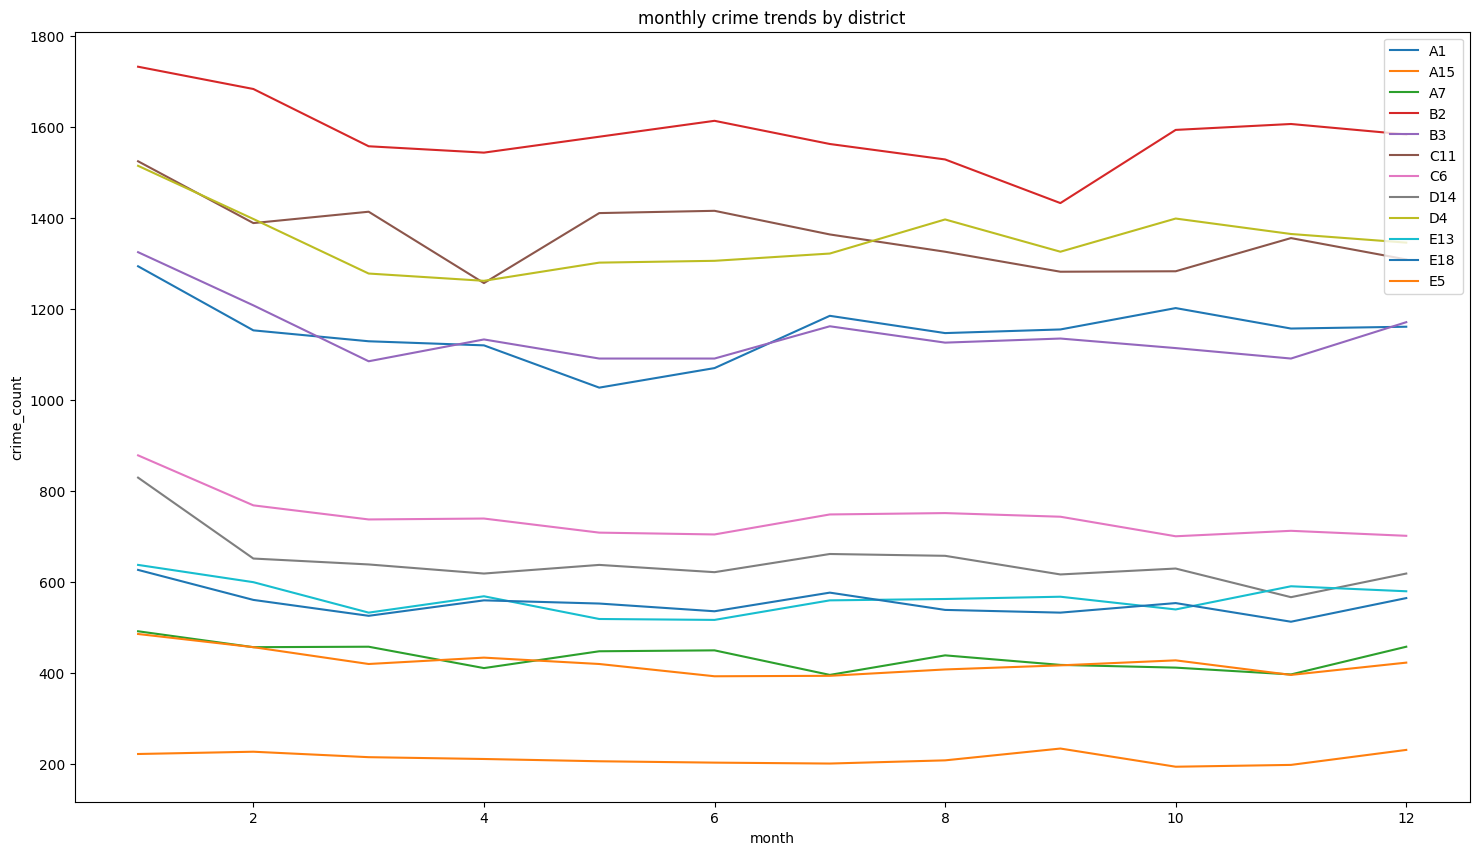

In [41]:
#line graph for crime trends 
monthly= df.groupby(["month","DISTRICT"],observed=True).size().reset_index(name="crime_count").sort_values(by="month")
pivot_df=monthly.pivot(index="month",columns="DISTRICT",values="crime_count")
pivot_df=pivot_df.drop(columns="UNKNOWN",errors = "ignore")
pivot_df.plot(kind ="line",figsize=(18,10))
plt.ylabel("crime_count")
plt.title("monthly crime trends by district")
plt.legend(loc="upper right")
plt.show()

In [42]:
#crime count by crime code group
df.groupby("OFFENSE_CODE_GROUP").size().reset_index(name="crime_count").sort_values("crime_count")

,OFFENSE_CODE_GROUP,crime_count
7,Biological Threat,2
9,Burglary - No Property Taken,2
26,HUMAN TRAFFICKING - INVOLUNTARY SERVITUDE,2
30,INVESTIGATE PERSON,4
25,HUMAN TRAFFICKING,7
...,...,...
46,Other,17881
31,Investigate Person,18750
40,Medical Assistance,22325
34,Larceny,25935
